# Faza 2: Optyczna Detekcja Tekstu (Text Detection) na pełnych dokumentach

## 1. Wstęp i założenia eksperymentu
Celem tej fazy jest wyłonienie optymalnego detektora (Text Detector), który posłuży jako pierwszy etap (Stage 1) w architekturze Two-Stage OCR. Algorytm musi precyzyjnie zlokalizować linie odręcznego tekstu na sfotografowanym dokumencie A4 i wygenerować ramki otaczające (Bounding Boxes), ignorując jednocześnie tło, marginesy i ewentualne artefakty wizualne. 

Zbadane zostaną różne podejścia architektoniczne (m.in. modele oparte o analizę gęstości znaków - CRAFT, oraz detektory obiektów - YOLO). W pierwszej kolejności ładujemy i standaryzujemy obraz wejściowy, aby uniknąć problemu przepełnienia pamięci (OOM) oraz zniekształceń skali (Scale Variance).

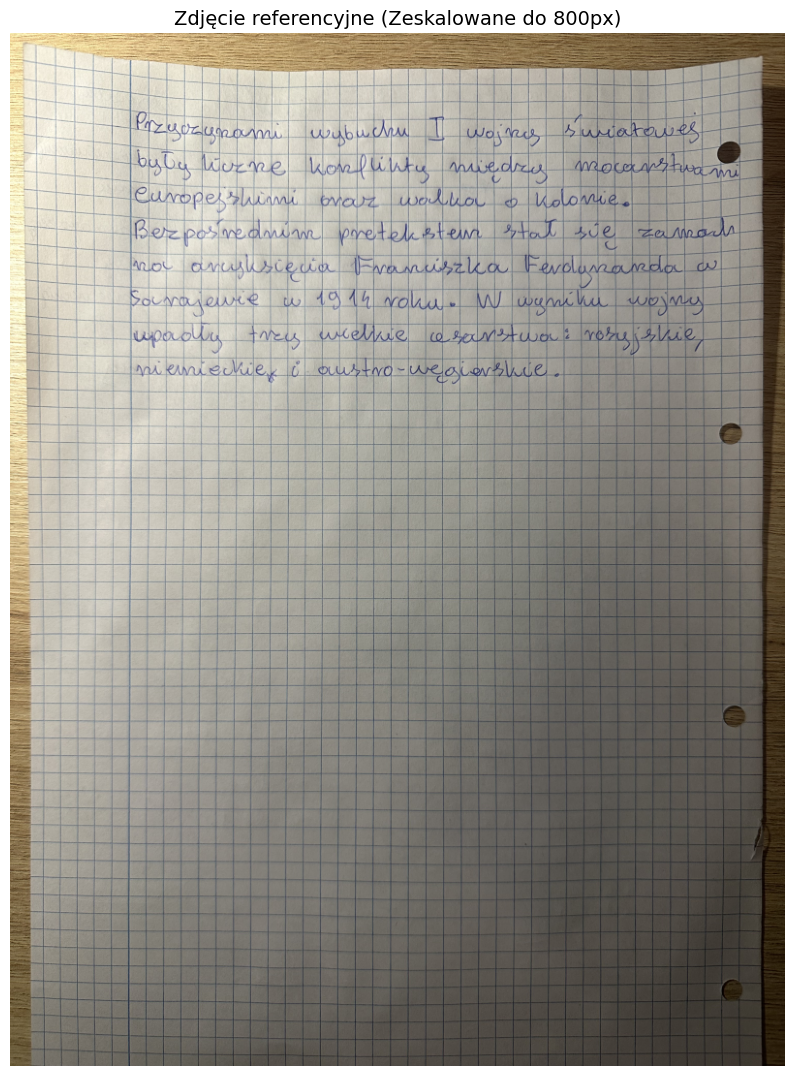

Nowa rozdzielczosc: 800x1066


In [13]:
import cv2
import imutils
import matplotlib.pyplot as plt
import numpy as np
def get_images(path):
    
    image = cv2.imread(path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    image_resized = imutils.resize(image_rgb, width=800)
    
    image_bgr_resized = cv2.cvtColor(image_resized, cv2.COLOR_RGB2BGR)

    return image_resized, image_bgr_resized
a, b= get_images("TestImageForSegmentation.jpeg")
plt.figure(figsize=(10, 14))
plt.imshow(a)
plt.title("Zdjęcie referencyjne (Zeskalowane do 800px)", fontsize=14)
plt.axis('off')
plt.show()

print(f"Nowa rozdzielczosc: {a.shape[1]}x{a.shape[0]}")

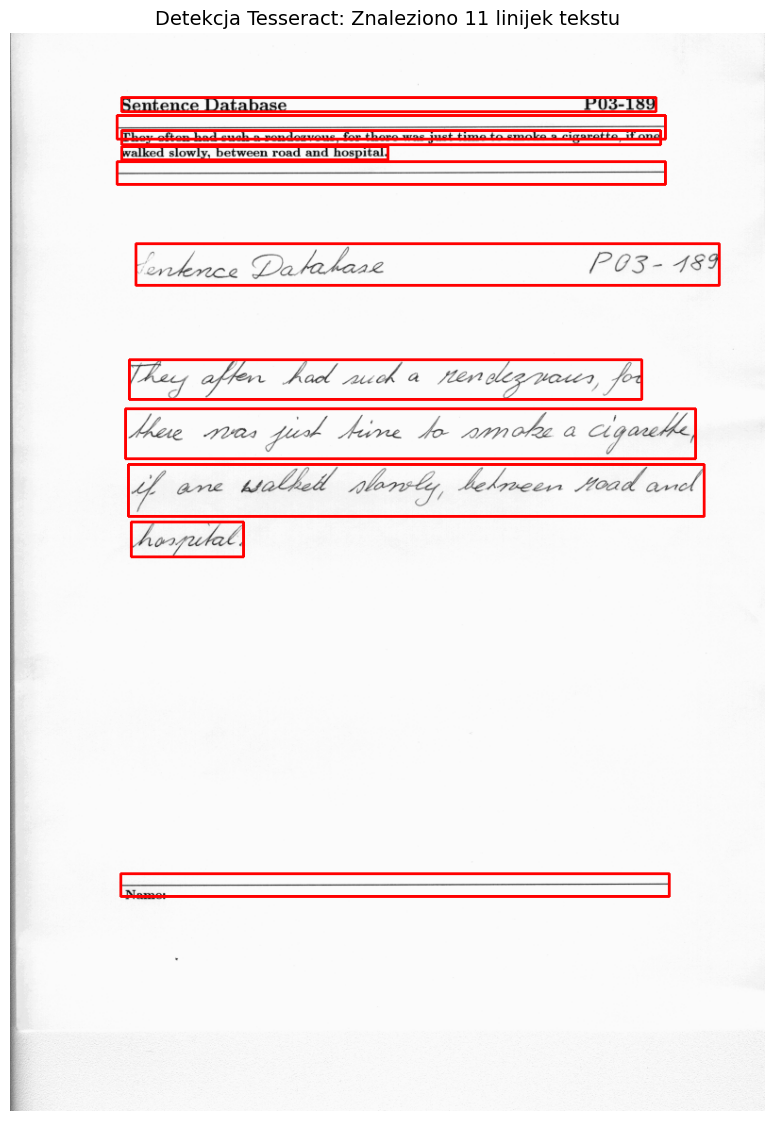

In [14]:
import cv2
import pytesseract
from pytesseract import Output
import matplotlib.pyplot as plt


pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

x, y = get_images("p03-189.png")

def draw_lines(img_resized, img_bgr_resized):
    tess_image = img_resized.copy()
    
    d = pytesseract.image_to_data(img_bgr_resized, output_type=Output.DICT)
    
    boxes_count = 0
    n_boxes = len(d['level'])
    
    for i in range(n_boxes):
    
        if d['level'][i] == 4:
    
            (x, y, w, h) = (d['left'][i], d['top'][i], d['width'][i], d['height'][i])
    
            if w > 10 and h > 10:
                cv2.rectangle(tess_image, (x, y), (x + w, y + h), (255, 0, 0), 2) 
                boxes_count += 1
    
    plt.figure(figsize=(10, 14))
    plt.imshow(tess_image)
    plt.title(f"Detekcja Tesseract: Znaleziono {boxes_count} linijek tekstu", fontsize=14)
    plt.axis('off')
    plt.show()
draw_lines(x, y)

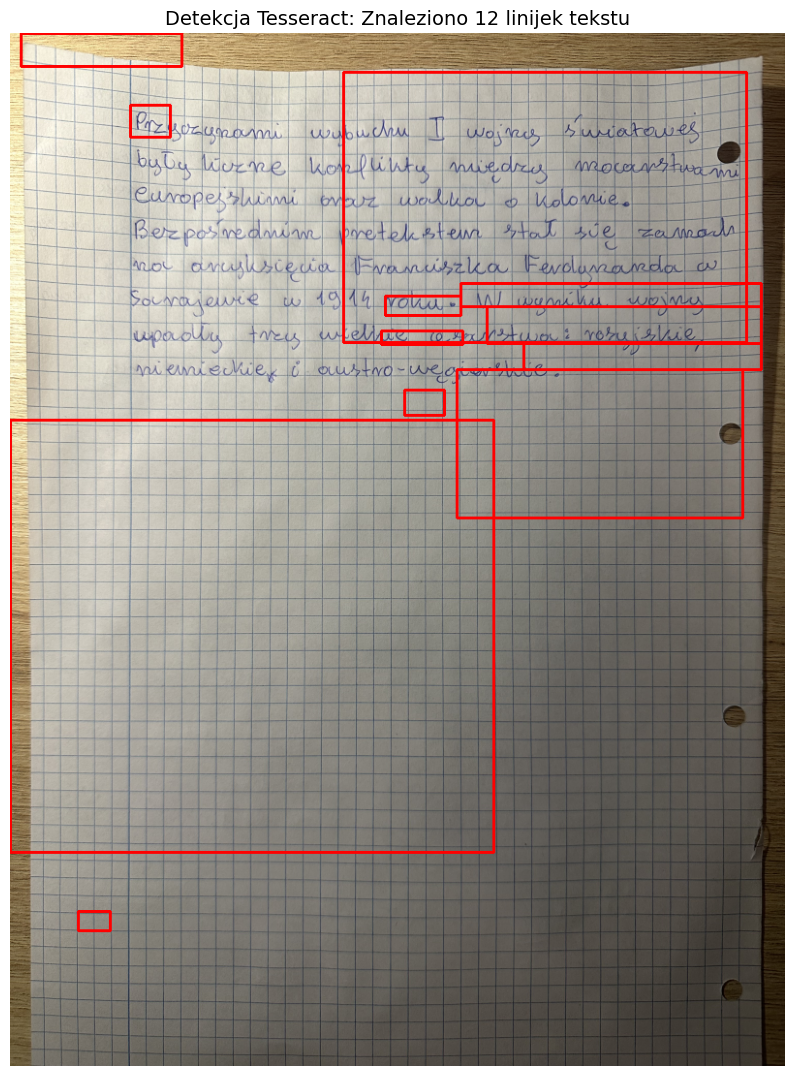

In [18]:
draw_lines(a, b)